# DiscountMate Behavioural Clustering Modelling

## Objective

The objective of this notebook is to apply clustering techniques to the preprocessed DiscountMate behavioural data and identify meaningful groups of users based on their GA4 behavioural patterns.

The modelling focuses on K-means and DBSCAN clustering, followed by evaluating the clustering results and identifying the behavioural characteristics of each cluster. The resulting clusters will then be provided as input for the subsequent persona interpretation stage.

## 1. Load the Clustering-Ready Data

In [1]:
# importing necessary libraries
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

In [2]:
# load the dataset

df = pd.read_csv("discountmate_clustering_ready_minmax_20260831.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (1500, 15)


,user_pseudo_id,mm_sessions_count,mm_avg_engagement_time_sec,mm_pageviews_per_session,mm_compare_ratio,mm_specials_ratio,mm_mylists_ratio,mm_category_browse_ratio,mm_product_detail_ratio,mm_unique_pages_visited,mm_browsing_entropy,mm_days_since_first_visit,mm_days_since_last_activity,reporting_window_start,reporting_window_end
0,syn_20260831_000001,0.000000,0.035220,0.08375,0.000000,0.000000,0.000000,0.1528,0.085000,0.055556,0.013176,0.692308,1.0,2026-08-17,2026-08-30
1,syn_20260831_000002,0.571429,0.644000,0.98125,0.176571,0.198286,0.916667,0.6692,0.232333,0.944444,0.882353,1.000000,0.1,2026-08-17,2026-08-30
2,syn_20260831_000003,0.285714,0.536678,0.44625,0.280571,0.029714,0.333333,0.6056,1.000000,0.333333,0.508588,0.615385,0.6,2026-08-17,2026-08-30
3,syn_20260831_000004,0.428571,0.314576,0.59250,0.963143,0.878000,0.077667,0.2000,0.073000,0.666667,0.797765,0.538462,0.0,2026-08-17,2026-08-30
4,syn_20260831_000005,0.571429,0.304712,0.62375,0.428571,0.889429,0.130667,0.5368,0.262667,0.722222,0.989176,0.538462,0.4,2026-08-17,2026-08-30


Before we start with the modelling features, let's see what those 15 columns are.

In [3]:
# Check the column names
for i, col in enumerate(df.columns, start=1):
    print(i, col)

1 user_pseudo_id
2 mm_sessions_count
3 mm_avg_engagement_time_sec
4 mm_pageviews_per_session
5 mm_compare_ratio
6 mm_specials_ratio
7 mm_mylists_ratio
8 mm_category_browse_ratio
9 mm_product_detail_ratio
10 mm_unique_pages_visited
11 mm_browsing_entropy
12 mm_days_since_first_visit
13 mm_days_since_last_activity
14 reporting_window_start
15 reporting_window_end


 Let's define the behavioural features

It is because for modelling, we need to separate the userID and reporting dates from the behavioural features.

In [4]:
features = [
    "mm_sessions_count",
    "mm_avg_engagement_time_sec",
    "mm_pageviews_per_session",
    "mm_compare_ratio",
    "mm_specials_ratio",
    "mm_mylists_ratio",
    "mm_category_browse_ratio",
    "mm_product_detail_ratio",
    "mm_unique_pages_visited",
    "mm_browsing_entropy",
    "mm_days_since_first_visit",
    "mm_days_since_last_activity"
]
print("Number of modelling features:", len(features))

Number of modelling features: 12


Since the team has already completed preprocessing, let's create the modelling matrix from the 12 mm_ features.

In [5]:
X = df[features].copy()


print("Modelling data shape:", X.shape)
X.head()

Modelling data shape: (1500, 12)


,mm_sessions_count,mm_avg_engagement_time_sec,mm_pageviews_per_session,mm_compare_ratio,mm_specials_ratio,mm_mylists_ratio,mm_category_browse_ratio,mm_product_detail_ratio,mm_unique_pages_visited,mm_browsing_entropy,mm_days_since_first_visit,mm_days_since_last_activity
0,0.000000,0.035220,0.08375,0.000000,0.000000,0.000000,0.1528,0.085000,0.055556,0.013176,0.692308,1.0
1,0.571429,0.644000,0.98125,0.176571,0.198286,0.916667,0.6692,0.232333,0.944444,0.882353,1.000000,0.1
2,0.285714,0.536678,0.44625,0.280571,0.029714,0.333333,0.6056,1.000000,0.333333,0.508588,0.615385,0.6
3,0.428571,0.314576,0.59250,0.963143,0.878000,0.077667,0.2000,0.073000,0.666667,0.797765,0.538462,0.0
4,0.571429,0.304712,0.62375,0.428571,0.889429,0.130667,0.5368,0.262667,0.722222,0.989176,0.538462,0.4


## 2. K-means Clustering

K-means clustering is used to group users based on similarities in their behavioural features. Different values of K will be tested and evaluated using inertia and silhouette score to identify a suitable number of clusters.

In [6]:
# To remove warning
import os
os.environ["LOKY_MAX_CPU_COUNT"] = "4"

In [7]:
# Test different numbers of clusters

k_values = range(2, 9)

inertias = []
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(X)
    
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X, labels))

# Display the results
k_results = pd.DataFrame({
    "k": list(k_values),
    "inertia": inertias,
    "silhouette_score": silhouette_scores
})

k_results

,k,inertia,silhouette_score
0,2,792.031605,0.364426
1,3,518.679975,0.410934
2,4,323.888774,0.483568
3,5,305.021323,0.377845
4,6,287.019799,0.311713
5,7,277.648665,0.226420
6,8,266.880342,0.166990


## 3. K-means Cluster Evaluation

We will use the elbow method to examine how inertia changes as the number of clusters increases. A suitable K can be identified where adding more clusters provides diminishing improvement.

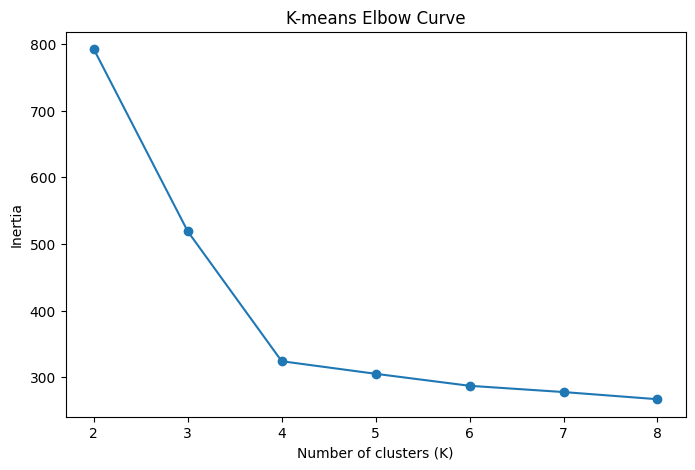

In [8]:
# Elbow curve

plt.figure(figsize=(8, 5))

plt.plot(
    k_results["k"],
    k_results["inertia"],
    marker="o"
)

plt.xlabel("Number of clusters (K)")
plt.ylabel("Inertia")
plt.title("K-means Elbow Curve")
plt.xticks(k_results["k"])
plt.show()

The elbow curve shows that there is a sharp drop in inertia as the number of clusters increases from K=2 to K=4. After K=4, the decrease is much smaller, so adding more clusters does not improve the results as much. This suggests that K=4 could be a suitable number of clusters for our data.

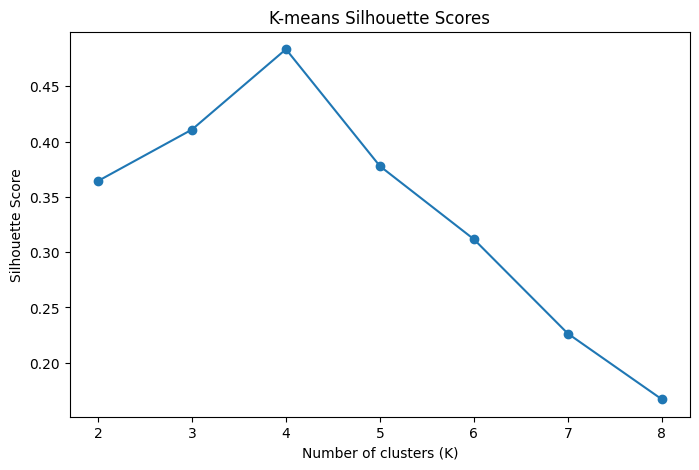

In [9]:
# Silhouette score plot

plt.figure(figsize=(8, 5))

plt.plot(
    k_results["k"],
    k_results["silhouette_score"],
    marker="o"
)

plt.xlabel("Number of clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("K-means Silhouette Scores")
plt.xticks(k_results["k"])
plt.show()

The above silhouette score increases from K=2 to K=4 and reaches its highest value of 0.484 at K=4. After that, the score starts to decrease as more clusters are added. Since K=4 has the highest silhouette score and also matches the point where the elbow starts to level off. So, K=4 seems to be the best option for our K-means model.

## 4. Build K-means Model

Based on the elbow curve and silhouette score, K=4 is selected for the final K-means model. So, let's fit the model using four clusters, and each user will be assigned to the cluster that best matches their behavioural pattern.

In [10]:
# Build the final K-means model with 4 clusters

kmeans_model = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans_model.fit_predict(X)

df["kmeans_cluster"] = cluster_labels

print("K-means clustering completed.")
print("\nNumber of users in each cluster:")
print(df["kmeans_cluster"].value_counts().sort_index())

K-means clustering completed.

Number of users in each cluster:
kmeans_cluster
0    300
1    525
2    300
3    375
Name: count, dtype: int64


## 5. K-means Cluster Profiles

Now that the users have been assigned to four clusters, we will compare the average behavioural features of each cluster. This will help us understand how the clusters differ and identify the main behavioural patterns within each group.

In [11]:
# Compare the average behavioural features across clusters

cluster_profiles = df.groupby("kmeans_cluster")[features].mean()

cluster_profiles

,mm_sessions_count,mm_avg_engagement_time_sec,mm_pageviews_per_session,mm_compare_ratio,mm_specials_ratio,mm_mylists_ratio,mm_category_browse_ratio,mm_product_detail_ratio,mm_unique_pages_visited,mm_browsing_entropy,mm_days_since_first_visit,mm_days_since_last_activity
kmeans_cluster,,,,,,,,,,,,
0,0.291429,0.703415,0.355037,0.153997,0.071210,0.103109,0.682773,0.764316,0.321481,0.561398,0.583333,0.244333
1,0.504762,0.385190,0.500319,0.728546,0.724439,0.084246,0.409150,0.172248,0.536085,0.849098,0.581978,0.194857
2,0.021905,0.070266,0.080971,0.019190,0.017483,0.020003,0.125289,0.084803,0.024074,0.145931,0.521795,0.291000
3,0.712000,0.537185,0.679477,0.285155,0.279240,0.736922,0.599754,0.331150,0.721926,0.737011,0.633641,0.152000


Because the features are already min-max scaled, the values are between 0 and 1, so we can compare the relative behaviour accross clusters.

In [12]:
# Create a cleaner table for comparing cluster behaviour

cluster_profiles_rounded = cluster_profiles.round(3)

cluster_profiles_rounded

,mm_sessions_count,mm_avg_engagement_time_sec,mm_pageviews_per_session,mm_compare_ratio,mm_specials_ratio,mm_mylists_ratio,mm_category_browse_ratio,mm_product_detail_ratio,mm_unique_pages_visited,mm_browsing_entropy,mm_days_since_first_visit,mm_days_since_last_activity
kmeans_cluster,,,,,,,,,,,,
0,0.291,0.703,0.355,0.154,0.071,0.103,0.683,0.764,0.321,0.561,0.583,0.244
1,0.505,0.385,0.500,0.729,0.724,0.084,0.409,0.172,0.536,0.849,0.582,0.195
2,0.022,0.070,0.081,0.019,0.017,0.020,0.125,0.085,0.024,0.146,0.522,0.291
3,0.712,0.537,0.679,0.285,0.279,0.737,0.600,0.331,0.722,0.737,0.634,0.152


### Cluster Profile Overview

The cluster profiles show clear differences in user behaviour. The clusters vary in terms of engagement, browsing activity, feature usage and overall exploration. These differences will be used to understand the characteristics of each behavioural segment before comparing them with the T1 personas.

In [13]:
# Now, let's identify the strongest behavioural features in each cluster

for cluster in cluster_profiles_rounded.index:
    print(f"\nCluster {cluster}")
    print("-" * 30)
    
    strongest = cluster_profiles_rounded.loc[cluster].sort_values(
        ascending=False
    ).head(5)
    
    print(strongest)


Cluster 0
------------------------------
mm_product_detail_ratio       0.764
mm_avg_engagement_time_sec    0.703
mm_category_browse_ratio      0.683
mm_days_since_first_visit     0.583
mm_browsing_entropy           0.561
Name: 0, dtype: float64

Cluster 1
------------------------------
mm_browsing_entropy          0.849
mm_compare_ratio             0.729
mm_specials_ratio            0.724
mm_days_since_first_visit    0.582
mm_unique_pages_visited      0.536
Name: 1, dtype: float64

Cluster 2
------------------------------
mm_days_since_first_visit      0.522
mm_days_since_last_activity    0.291
mm_browsing_entropy            0.146
mm_category_browse_ratio       0.125
mm_product_detail_ratio        0.085
Name: 2, dtype: float64

Cluster 3
------------------------------
mm_mylists_ratio            0.737
mm_browsing_entropy         0.737
mm_unique_pages_visited     0.722
mm_sessions_count           0.712
mm_pageviews_per_session    0.679
Name: 3, dtype: float64


### Cluster Behaviour Interpretation

The four clusters show different patterns of user behaviour.

**Cluster 0** has relatively high engagement time, category browsing and product-detail activity. So these users appear to spend more time browsing and looking at products. 

**Cluster 1** stands out more for comparison and specials activity, as well as high browsing diversity.

**Cluster 2** represents users with very low overall activity across most behavioural features. It's basically the least active group.

**Cluster 3** has the highest overall activity, with strong use of My Lists, high browsing diversity, more sessions and more pages visited. 

These differences provide a basis for comparing the clusters with the existing T1 personas.

## 6. Visualising the K-means Clusters

We will use Principal Component Analysis (PCA) to reduce the behavioural features to two dimensions. We have multiple behavioural features, so PCA helps reduce that into two components so that the four K-means clusters can be visualised.

In [14]:
# Reduce the behavioural features to two dimensions
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

# Create a dataframe for visualisation
pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_df["kmeans_cluster"] = df["kmeans_cluster"]

print("Explained variance:")
print(pca.explained_variance_ratio_)

Explained variance:
[0.44707076 0.23186538]


The first two components explained approximately 67.9% of the variation in the data. So, let's visualise the k-means clusters.

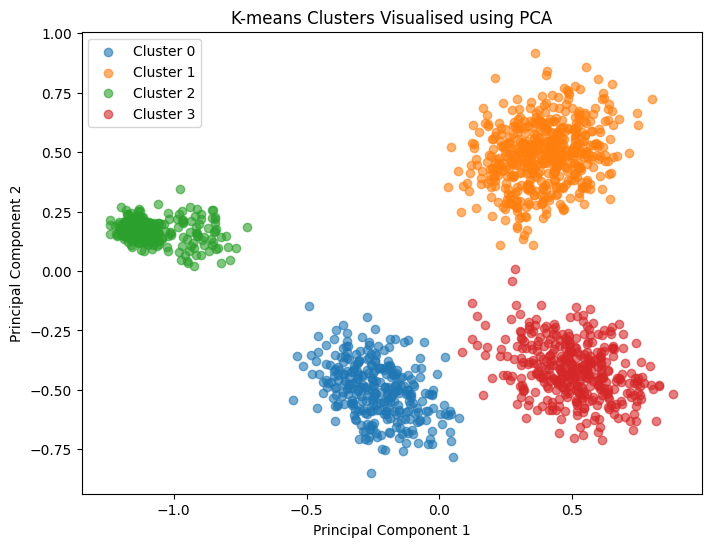

In [15]:
# Visualise the K-means clusters using PCA

plt.figure(figsize=(8, 6))

for cluster in sorted(pca_df["kmeans_cluster"].unique()):
    cluster_data = pca_df[pca_df["kmeans_cluster"] == cluster]
    
    plt.scatter(
        cluster_data["PC1"],
        cluster_data["PC2"],
        label=f"Cluster {cluster}",
        alpha=0.6
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-means Clusters Visualised using PCA")
plt.legend()
plt.show()

### PCA Cluster Visualisation – Interpretation

The PCA plot shows that the four K-means clusters are well separated in the two-dimensional space. Cluster 2 is clearly separated on the left, while Clusters 1 and 3 are mainly positioned in the upper-right and lower-right areas. Cluster 0 sits mostly in the lower-middle area. There is negligible overlap between the clusters, so, the groups are reasonably distinct, which supports using K=4 for the clustering.

## Comparing cluster sizes

Next, let's make a bar chart to show how many users are in each cluster. This is useful because we already know the counts, but a chart makes the result easier to understand in the final document/presentation.

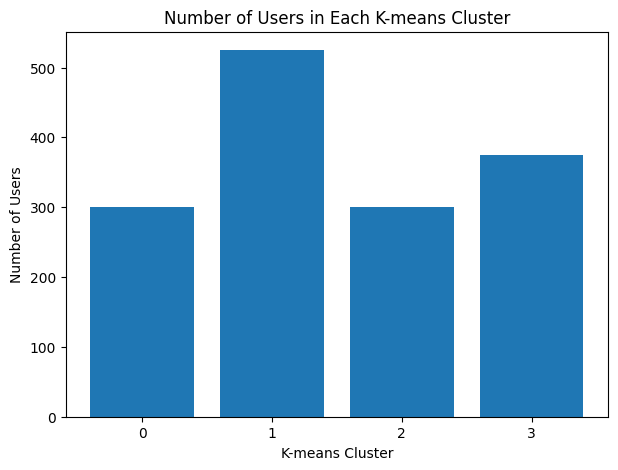

In [16]:
# Visualise the number of users in each cluster

cluster_counts = df["kmeans_cluster"].value_counts().sort_index()

plt.figure(figsize=(7, 5))

plt.bar(
    cluster_counts.index.astype(str),
    cluster_counts.values
)

plt.xlabel("K-means Cluster")
plt.ylabel("Number of Users")
plt.title("Number of Users in Each K-means Cluster")

plt.show()

### Cluster Size – Interpretation

The cluster sizes shows that Cluster 1 is the largest group, with 525 users, followed by Cluster 3 with 375 users. Clusters 0 and 2 each contain 300 users. This shows that the four clusters are not evenly sized, but there are still a reasonable number of users in each group for further behavioural analysis.

## 7. Cluster Behaviour Heatmap

Let's create a heatmap to compare the behavioural features across the four clusters. This makes it easier to identify which behaviours are relatively high or low within each cluster.

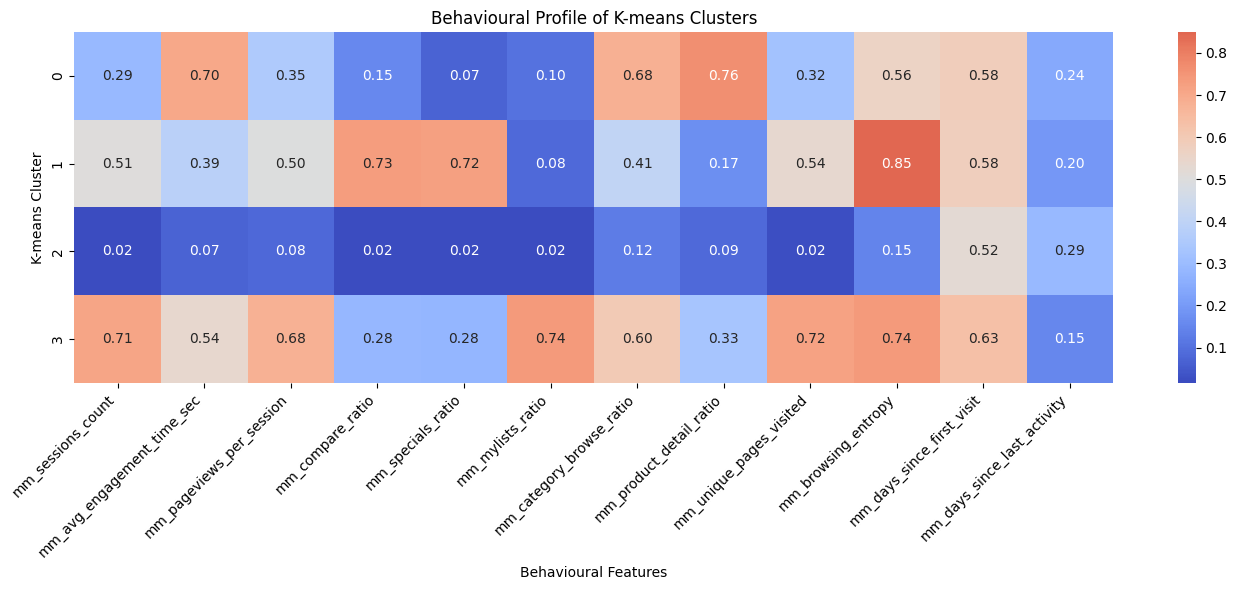

In [17]:
plt.figure(figsize=(14, 6))

sns.heatmap(
    cluster_profiles_rounded,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0.5
)

plt.title("Behavioural Profile of K-means Clusters")
plt.xlabel("Behavioural Features")
plt.ylabel("K-means Cluster")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Heatmap Interpretation

The heatmap gives us a clearer view of how the four clusters behave differently. Cluster 0 shows more engagement with product details and category browsing, while Cluster 1 is more focused on comparing products and looking at specials. Cluster 2 has much lower activity across most of the features, suggesting these users interact with DiscountMate less overall. Cluster 3 shows higher overall activity, especially in My Lists, sessions, pages visited and browsing behaviour. Overall, the heatmap shows that the four groups have some clear differences in how they use the platform.

## 8. DBSCAN Clustering

DBSCAN was also tested as an alternative clustering method. It was used to see whether it could identify similar behavioural groups and any users that did not fit clearly into a cluster.

In [18]:
# DBSCAN with a reasonable starting configuration
dbscan = DBSCAN(
    eps=0.30,
    min_samples=10,
    metric="euclidean"
)

dbscan_labels = dbscan.fit_predict(X)

# Add DBSCAN labels to the dataset
df["dbscan_cluster"] = dbscan_labels

print("Number of clusters:", len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0))
print("Number of noise points:", (dbscan_labels == -1).sum())

print("\nUsers in each DBSCAN cluster:")
print(df["dbscan_cluster"].value_counts().sort_index())

Number of clusters: 1
Number of noise points: 1207

Users in each DBSCAN cluster:
dbscan_cluster
-1    1207
 0     293
Name: count, dtype: int64


### DBSCAN Results

DBSCAN was tested as an alternative clustering method. With the selected parameters, it identified one main cluster containing 293 users, while 1,207 users were classified as noise. This did not provide a useful segmentation of the users into multiple behavioural groups. Therefore, K-means provides a more useful clustering solution for this dataset and will be used as the main method for the persona analysis.

## 9. Modelling Conclusion

K-means and DBSCAN were both tested on the behavioural dataset. K-means gave us a clearer and more useful segmentation, with K=4 selected based on the elbow curve and the highest silhouette score of 0.484. The PCA plot also showed clear separation between the four clusters.

DBSCAN was tested as an alternative, but it resulted in one main cluster and a large number of users being classified as noise. Because of this, it did not provide a useful segmentation for our dataset.

Based on these results, we decided to use the K=4 K-means solution for the next stage. The cluster assignments, cluster sizes and behavioural profiles will be passed on for the persona interpretation and comparison with the T1 personas.